
<div style="background-color:rgba(250, 250, 250, 0.1)">

---
# 📈  `Simple (einfache) LINEARE Regression`

#### Inhalt
- Geradengleichung
- MAE, MSE und R²

---

Bei der Linearen Regression versucht man  ``eine Gerade`` möglichst so zwischen die Daten zu legt, dass ``die Abweichung aller tatsächlichen Werte möglichst gering`` ist. 

&nbsp;&nbsp;&nbsp;&nbsp;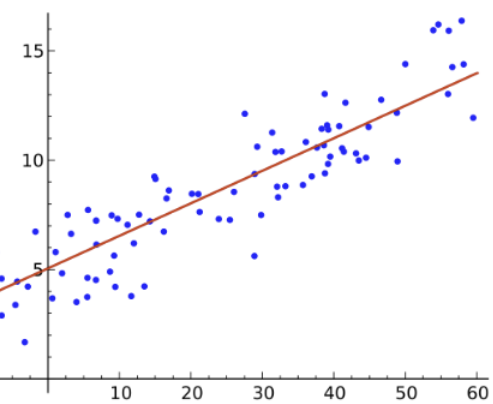

✨ Die Punkte der Geraden entsprechen dabei den Vorhersagen des Modells. Sie sind Schätzungen für den tatsächlichen Wert.


---
<div style="text-align: center; background-color: #2f302eff; color: #e6e6e3d8; padding: 8px; border-radius: 6px;">©2025 Prof. Gaisberger</div>

---
</div>

Jede Gerade kann mit einer Gleichung dargestellt werden.

>####  $ f(x) = k \cdot x + d $  
>
> Dabei sind die **Koeffizienten**:
> - **``k``** die Steigung (*`Coefficient`*) und 
> - **``d``** der Schnittpunkt (*`Intercept`*) mit der y-Achse



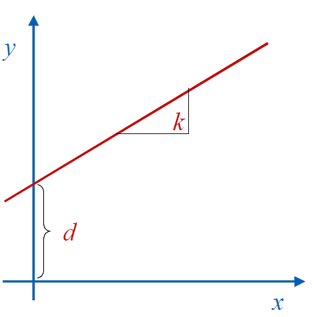

Die ``Lineare Regression`` versucht nun diese beiden Koeffizienten zu finden, so dass ``die Abweichung aller Punkte zur Geraden möglichst gering`` ist.


<div style="background-color:rgba(250, 250, 0, 0.1)">

---

# Aufgabe: 

Aus der ``Sepal-Länge`` einer Iris soll die ``Petal-Länge`` vorausgesagt werden.  

Da für die Vorhersage **NUR EIN EINZIGES** Feature vorhanden ist, reicht eine ``SIMPLE Lineare Regression`` als Modell.


---



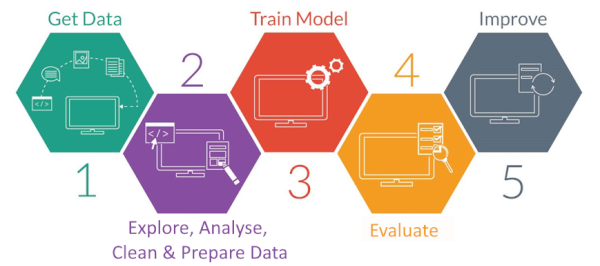

---
# 🟨 `Schritt 1:` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_iris` verwendet. Es ist ein Übungsdataset, welches von `sklearn` zur Verfügung gestellt wird. Es wird in einem internen Format geladen und muss danach in ein `Dataframe` umgewandelt werden.

In [16]:
from sklearn import datasets
import pandas as pd

# Laden der Daten
iris = datasets.load_iris()

# Neues DataFrame mit den Iris-Daten (Features) erzeugen
dfIris = pd.DataFrame(iris.data, columns = iris.feature_names)

dfIris['species'] = iris.target
dfIris['speciesname'] = dfIris['species'].replace({0:'setosa',1:'versicolor', 2:'virginica'})

dfIris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,speciesname
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


---
# 🟨 `Schritt 2:` Benötigte Daten auswählen

Für das Machine Learning Modell ist es sinnvoll ein neues Dataframe zu erstellen, welches nur die `Daten und Features` enthält, welche für das jeweilige Modell benötigt werden bzw. am besten für die Vorhersage geeignet sind



In [17]:
cols_df = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)', 'species', 'speciesname']

dfIris = dfIris[cols_df]
dfIris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,speciesname
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Daten auswählen

Das *`Zielmerkmal`* (Target), das vorhergesagt werden soll, ist die **Petal-Länge**. Für ihre Vorhersage wählen wir als *`Eingabemerkmal`* (Feature) die **Sepal-Länge** aus. 

Wir trennen also die Daten in zwei DataFrames auf:
- `dfLearn_X` enthält nur die *Sepal-Länge* (unabhängige Variable)  
- `dfLearn_Y` enthält nur die *Petal-Länge* (abhängige Variable)

So stellen wir sicher, dass das Modell ausschließlich auf Basis der Sepal-Länge trainiert und getestet wird, um daraus die Petal-Länge vorherzusagen.


In [18]:
#------------------------------------------------------------
# ✨ Features auswählen (Liste mit den Spaltennamen)
cols_x  = ['sepal length (cm)']        # independent
target  = 'petal length (cm)'          # dependent: Vorhersagen

#----------------------------------------------------------------------
dfLearn_X = dfIris[cols_x]
dfLearn_Y = dfIris[target]

<div style="background-color:rgba(250, 250, 250, 0.1)">

---
##### ✨ Merke:
- **`X`** bezeichnet die sogenannte unabhängige (*`independent`*) Variable, also das Merkmal, das als Eingabe für das Modell dient.  
- **`y`** ist die abhängige (*`dependent`*) Variable, also das Ziel, das vorhergesagt werden soll.

**`X`** enthält somit die Werte, anhand derer das Modell lernt, **`y`** enthält die Werte, die das Modell vorhersagen soll.


---
</div>


### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
train_size = 0.7                  # 70% der Daten für Training verwenden
dfTrain_x, dfTest_x, dfTrain_y, dfTest_y = train_test_split( dfLearn_X, dfLearn_Y,
                train_size= train_size, 
                random_state=0)
                
#------------------------------------------------------------
# ✨ Dataframe in Array umrechnens
train_x = dfTrain_x.values       # independent
train_y = dfTrain_y.values       # dependent

test_x  = dfTest_x.values        # independent
test_y  = dfTest_y.values        # dependent
#------------------------------------------------------------

---
# 🟨 ``Schritt 3:`` Modell erstellen und trainieren


### Modell erstellen und trainieren

In [20]:
from sklearn import linear_model

#------------------------------------------------------------
# ✨ Modell erstellen und trainieren
model = linear_model.LinearRegression()
model.fit(train_x, train_y)

#------------------------------------------------------------
# ✨ Koeffizienten und Intercept (d) ausgeben
print ('Coefficients: k = ', model.coef_)
print ('Intercept:    d = ', model.intercept_)

Coefficients: k =  [1.81991363]
Intercept:    d =  -6.8967862264124005


<div style="background-color:rgba(250, 250, 250, 0.1)">

---
##### ✨ Zur Erinnerung:

**``Coefficient``** and **``Intercept``** sind die Parameter bei der Linearen Regression, mit denen die Verteilung der Trainingsdaten angenähert wird.

&nbsp;&nbsp;&nbsp;&nbsp;  $y = k \cdot x + d$

&nbsp;&nbsp;&nbsp;&nbsp;  **``k``** ist die Steigung  
&nbsp;&nbsp;&nbsp;&nbsp;  **``d``** ist der Schnittpunkt mit der y-Achse

Durch sie wird der Verlauf der Geraden festgelegt 

---
</div>

### Vorhersagen erstellen

Diese Koeffizienten ermöglichen es uns nun, für jeden gegebenen Wert der Sepal-Länge eine entsprechende Petal-Länge zu ermitteln - der Wert auf der Geraden.

Diese vorhergesagten Werte können anschließend mit den tatsächlichen Werten verglichen werden, um die Genauigkeit des Modells zu bewerten. Je kleiner die Abweichung zwischen Vorhersage und Realität, desto besser ist die Modellanpassung.

In [21]:

#------------------------------------------------------------
# ✨ Vorhersagen für die Trainingsdaten erstellen
pred_train_y = model.predict(train_x)

#------------------------------------------------------------
# ✨ Vorhersagen für die Testdaten erstellen
pred_y = model.predict(test_x)


### Vorhersagen visualisieren

Erstelle jeweils einen Scatterplot mit den Trainings- und Testdaten und zeichne weiters die vorhergesagten Werte des Modells ein.


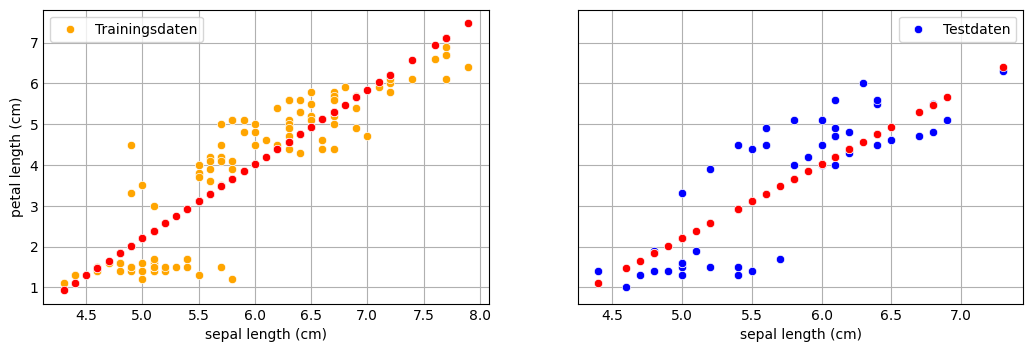

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,3), sharey=True)
plt.style.use('_mpl-gallery')

#------------------------------------------------------------
# Trainingsdaten ausgeben
sns.scatterplot(ax=axs[0], x=dfTrain_x['sepal length (cm)'], y=dfTrain_y,    color='orange')
sns.scatterplot(ax=axs[0], x=train_x[:,0],                   y=pred_train_y, color='red')

# Testdaten ausgeben
sns.scatterplot(ax=axs[1], x=dfTest_x['sepal length (cm)'],  y=dfTest_y, color='blue')
sns.scatterplot(ax=axs[1], x=test_x[:,0],                    y=pred_y,   color='red')

axs[0].legend(['Trainingsdaten'])
axs[1].legend(['Testdaten'])


---
# 🟨 `Schritt 4:` Evaluieren


## 🔷 Genauigkeit des Modells

Wir vergleichen die tatsächlichen Werte mit den vorhergesagten Werten, um die Genauigkeit eines Regressionsmodells zu berechnen. Bewertungsmethoden spielen eine wichtige Rolle bei der Entwicklung eines Modells, da sie Aufschluss über die Leistung und **Genauigkeit eines** Modells geben.

Eine **prozentuelle Genauigkeit** (*zB 80% sind richtig*) kann es nur bei kategorischen Daten geben und nicht bei kontinuierlichen. Deshalb benötigen wir für die Bewertung von Regressionsmodellen andere Methoden.

Die wichtigsten dafür sind: 
 - *`MSE`* - Mittlerer QUADRATISCHER Fehler
 - *`MSA`* - Mittlerer ABSOLUTER Fehler und
 - *`R²`-Score*

<div style="background-color:rgba(250, 250, 250, 0.1)">

---
##### ✨ **Mittlerer QUADRATISCHER Fehler (`MSE`)**:  

Der mittlere quadratische Fehler (MSE) ist der Mittelwert der quadratischen Abweichungen (*tatsächlicher Wert - vorhergesagter Wert*).

$MSE = \frac{1}{n}\sum_{i=1}^{n}(ŷ_i - y_i)^2$

Der Vorteil des MSE ist, dass er sich eher bei größeren Fehlern auswirkt. Dies ist darauf zurückzuführen, dass durch das Quadrat ``größere Fehler verstärkt`` und ``kleinere reduziert`` werden. 

Einzelne größere Abweichungen werden dadurch besser erkennbar, da der MSE dadurch schnell sehr hoch wird. 

---
</div>
 


<div style="background-color:rgba(250, 250, 250, 0.1)">

---
##### ✨ **Mittlerer ABSOLUTER Fehler (`MSA`)**:  


Der *mittlere absoluter Fehler (MSA)* ist der Mittelwert der absoluten (positiven) Abweichungen (*tatsächlicher Wert - vorhergesagter Wert*).  

$MSA = \frac{1}{n}\sum_{i=1}^{n}|ŷ_i - y_i|$

Der Vorteil des MSA ist, dass er **alle Fehler gleich bewertet**, aber keine Aussage möglich ist, ob einzelne Werte sehr stark abweichen. Diese werden im MSE besser erkannt.  

  
---
</div>

<div style="background-color:rgba(250, 250, 250, 0.1)">

---
##### ✨ **$R^2$-Score `(R-Quadrat)`**

**$R^2$-Score** ist kein Fehler, sondern eine beliebte Methode zur Messung der **Leistung eines Regressionsmodells**.  
Er ist ein Mass dafür, wie nahe die Datenpunkte an der ermittelten Regressionsgerade liegen.  

>| 👉 *Je höher der $R^2$-Score ist, desto besser ist das Modell.*
>|-----------------------
>| 👉 Der **bestmögliche Wert ist `1.0`**, 
>| 👉 er kann aber `auch negativ` sein (weil das Modell beliebig schlecht sein kann).
  
---
</div>

In [23]:
# --------------------------------------------------------------------------------------
# ✨ Trainingsdaten evaluieren
# Erstelle zuerst eine Vorhersage der Daten und gib die ersten 10 Werte aus
# Berechne anschliessend MSE, MAE und den R^2-Value
# --------------------------------------------------------------------------------------
import numpy as np
from sklearn import metrics

print("Testwerte y: ", np.around(train_y[:10],1))
print("Vorhersagen: ", np.around(pred_train_y[:10],1))

# ✨ MSE, MAE und R^2-Value ermitteln und ausgeben
print( "\nGenauigkeit bei Trainingsdaten:") 
print("\tMSE:      %12.2f" % metrics.mean_squared_error (train_y , pred_train_y) )
print("\tMAE:      %12.2f" % metrics.mean_absolute_error(train_y , pred_train_y) )
print("\tR2-score: %12.2f" % metrics.r2_score           (train_y , pred_train_y) )

Testwerte y:  [3.5 5.5 5.7 5.  5.8 3.9 6.1 4.7 3.8 4.9]
Vorhersagen:  [2.2 4.9 5.3 4.  5.3 3.3 7.1 4.6 3.1 4.6]

Genauigkeit bei Trainingsdaten:
	MSE:              0.70
	MAE:              0.68
	R2-score:         0.78


In [24]:
# --------------------------------------------------------------------------------------
# ✨ Testdaten evaluieren
# Erstelle zuerst eine Vorhersage der Daten und gib die ersten 10 Werte aus
# Berechne anschliessend MSE, MAE und den R^2-Value
# --------------------------------------------------------------------------------------
import numpy as np
from sklearn import metrics

print("Testwerte y: ", np.around(test_y[:10],1))
print("Vorhersagen: ", np.around(pred_y[:10],1))

# ✨ MSE, MAE und R^2-Value ermitteln und ausgeben
print( "\nGenauigkeit bei Testdaten:") 
print("\tMSE:      %12.2f" % metrics.mean_squared_error (test_y , pred_y) )
print("\tMAE:      %12.2f" % metrics.mean_absolute_error(test_y , pred_y) )
print("\tR2-score: %12.2f" % metrics.r2_score           (test_y , pred_y) )

Testwerte y:  [5.1 4.  1.4 6.3 1.5 6.  1.3 4.7 4.8 4. ]
Vorhersagen:  [3.7 4.  3.1 6.4 2.2 4.6 2.2 5.3 5.5 4.2]

Genauigkeit bei Testdaten:
	MSE:              0.84
	MAE:              0.76
	R2-score:         0.69


<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Was kannst du über die Genauigkeit (MSE und des $R^2$-Value) des Models sagen?**<br>
Ein MSE von 0.84 ist relativ niedrig, was darauf hindeutet, dass das Modell im Durchschnitt eine geringe Abweichung von den tatsächlichen Werten hat.

Ein MAE von 0.76 deutet darauf hin, dass die durchschnittliche Größe des Fehlers gering ist. Da MAE weniger empfindlich auf Ausreißer reagiert als MSE, zeigt dieser Wert, dass das Modell über alle Vorhersagen hinweg relativ konsistent ist.

Ein R2-Score von 0.69 zeigt an, dass das Modell etwa 69% der Variabilität der tatsächlichen Daten erklärt, was ein akzeptables, aber nicht hervorragendes Ergebnis darstellt.

Es scheint, dass das Modell für einige Datenpunkte präzise Vorhersagen macht, aber für andere weniger genau ist, was darauf hinweisen könnte, dass es bestimmte Muster in den Daten gibt, die das Modell nicht vollständig erfasst. 

`Da die R2-Scores von Test- und Trainingsdaten ähnlich sind, scheint das Modell auch nicht zu Overfitting zu neigen.`  
**`Insgesamt scheint das Modell gut angepasst zu sein und gute Vorhersagen zu liefern, sollte aber noch weiter verbessert werden.`**

---
</div>

## 🔷 Visueller Vergleich der Genauigkeit

Eine gute Möglichkeit für die Evaluierung ist die Verteilung 
- die Verteilung der wirklichen Daten (Training- oder Testdaten) und
- die Verteilung der vorhergesagten Werte

zu vergleichen

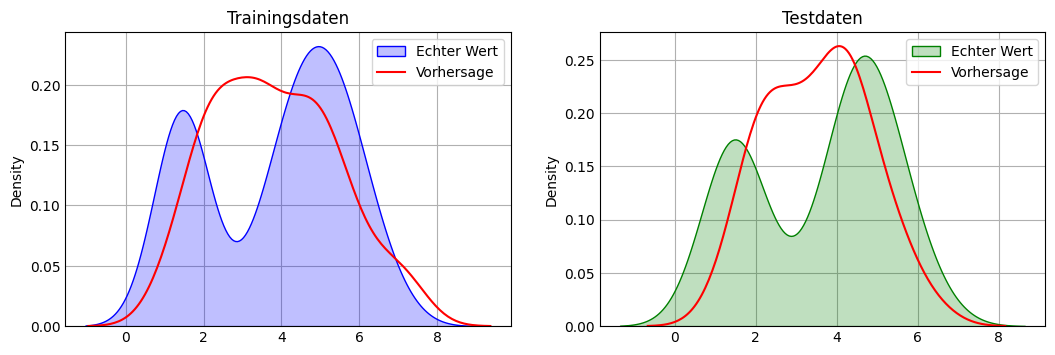

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
# ----------------------------------------------------------------------------
# ✨ Traininigsdaten: Verteilung der Vorhersagen und echten Werte plotten
axs[0].set(title="Trainingsdaten" )
sns.kdeplot(ax=axs[0], x=train_y,     color="blue",  fill=True, )
sns.kdeplot(ax=axs[0], x=pred_train_y,color="red",   )
axs[0].legend(['Echter Wert','Vorhersage'])

# ----------------------------------------------------------------------------
# ✨ Testdaten: Verteilung der Vorhersagen und echten Werte plotten
axs[1].set(title="Testdaten" )
sns.kdeplot(ax=axs[1], x=test_y, color="green", fill=True)
sns.kdeplot(ax=axs[1], x=pred_y, color="red",  )
axs[1].legend(['Echter Wert','Vorhersage'])

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Interpretiere die Diagramme in Bezug auf die Genauigkeit des Models!**<br>  
 
Die Flächen der tatsächlichen und der vorhergesagten Werte überlagern sich prinzipiell sehr gut, obwohl es in der Mitte bei den Daten jeweils einen Einbruch gibt, aber die Vorhersagen diesen nicht berücksichtigen.  

Die Abweichungen, die in beiden Diagrammen sichtbar sind, könnten auf systematische Fehler hinweisen, die das Modell beim Lernen dieser speziellen Datenpunkte gemacht hat, oder auf eine natürliche Varianz innerhalb des Datensatzes. 

Die ähnlichen Muster in beiden Diagrammen weisen darauf hin, dass das Modell nicht stark überangepasst ist, da die Vorhersagen für die Testdaten die tatsächlichen Daten gut wiedergeben. 

``Das lässt darauf schliessen, dass das Modell in diesem Bereich sehr ungenau ist und dort noch optimiert werden muss. zB durch Verwendung eines Polynoms``

---
</div>

---
# 🟨 Praxistest

Ein Praxistest wird durchgeführt, um zu überprüfen, wie gut das trainierte Modell auf neue, unbekannte Werte reagiert. Damit kann beurteilt werden, ob die Vorhersagen des Modells auch außerhalb der Trainings- und Testdaten sinnvoll und zuverlässig sind. So lässt sich die praktische Anwendbarkeit des Modells im Alltag bewerten.

> Ermittle die Petal-Länge für eine Iris mit einer Sepal-Länge von 4.6 


In [ ]:
# ✨ Einzelne Vorhersage machen
# Gib die Petal-Länge für eine Blume mit Sepal-Length=4.6 aus
sepallength = 4.6

# Vorhersage erstellen
petallength = model.predict([[sepallength]])
print("Petal-Länge: %.2f" % petallength[0])


<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Vergleiche das Ergebnis mit dem zugehörigen Wert aus den Beobachtungen?**<br>

Im Dataset entspricht eine Sepal-Länge von 4.6 einer Petal-Länge von 1.5.

Die Vorhersage von 1.47 ist ein guter Wert.

---
</div>

---
# 🟨 `Modell visuell darstellen`

Da bei der simplen linearen Regression nur ein Feature für das Modell verwendet wird, kann das Modell mit einer Geraden visulisiert werden.

Um eine gute Darstellung zu erhalten, ist es wichtig die ``Wertebereiche der Achsen`` entsprechend anzupassen! (min-Werte und max-Werte)

In [ ]:
# --------------------------------------------------------------------------------------
# ✨ Gib die Trainingsdaten mit echten und vorhergesagten Werten 
#  - als Scatterplot aus und
#  - zeichne die Regressionsgerade als Linie ein
# --------------------------------------------------------------------------------------
import seaborn as sns
plt.subplots(figsize=(5,3))

# ------------------------------------------------------------------
# Traininigsdaten: Echte Werte plotten
sns.scatterplot(x=train_x[:, 0], y=train_y, color='orange')

# Traininigsdaten: Vorhersagen plotten
sns.scatterplot(x=train_x[:, 0], y=pred_train_y, color='blue')

# ------------------------------------------------------------------
# Werte der Regressionsgeraden/-kurve berechnen
x = np.arange(dfIris['sepal length (cm)'].min(), 
              dfIris['sepal length (cm)'].max(), 0.5).reshape(-1, 1)

xp = model.predict(x)

# Regressionsgerade/-kurve plotten
sns.lineplot(x=x[:,0], y=xp, color='red')

plt.legend(['Trainingswerte', 'Vorhersagewerte', 'Regressionsgerade'])